# Real-Time Hallucination Monitoring for AI Compliance Agents
## groundlens + LangGraph: live pipeline verification over the EU AI Act

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/groundlens-dev/groundlens/blob/main/examples/eu_ai_act_live_pipeline.ipynb)

---

### What this notebook does

This notebook loads the **EU AI Act PDF** (144 pages), chunks it, builds a vector index, and runs a **real 3-agent compliance pipeline** with LangGraph. groundlens monitors every LLM call automatically.

Nothing is pre-written. The PDF goes in. The agents process it. groundlens watches.

| Agent | Role | groundlens metric |
|---|---|---|
| **Retriever** | Embeds the question, searches PDF chunks by cosine similarity | Retrieval relevance |
| **Compliance Analyst** | Answers the question from retrieved chunks (real LLM call) | SGI (grounded verification) |
| **Risk Assessor** | Evaluates compliance risk from the analysis (real LLM call) | SGI (grounded verification) |

### References

| Paper | Key finding |
|---|---|
| [Marin, "Semantic Grounding Index" (2025)](https://arxiv.org/abs/2512.13771) | Geometric bounds on context engagement in RAG |
| [Marin, "A Geometric Taxonomy of Hallucination" (2026)](https://arxiv.org/abs/2602.13224) | Three hallucination types with distinct geometric signatures |
| [EU AI Act](https://eur-lex.europa.eu/eli/reg/2024/1689/oj) | Regulation (EU) 2024/1689, 13 June 2024 |

## 1. Setup

| Key | Why | Where to get it |
|-----|-----|-----------------|
| **OpenAI** (`OPENAI_API_KEY`) | Powers the compliance analyst and risk assessor agents | [platform.openai.com/api-keys](https://platform.openai.com/api-keys) |
| **Hugging Face** (`HF_TOKEN`) | Downloads the sentence-transformer model (~90 MB) | [huggingface.co/settings/tokens](https://huggingface.co/settings/tokens) |

> **Anthropic alternative:** Replace `ChatOpenAI` with `ChatAnthropic` from `langchain_anthropic`. The groundlens callback works with any LangChain-compatible LLM.

In [1]:
# -- Install --
!pip install -q "groundlens[langgraph]==2026.5.22" langchain-openai langchain-community pypdf

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.1/66.1 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.6/98.6 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 22.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 338.8/338.8 kB 14.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 14.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 548.1/548.1 kB 8.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.9/275.9 kB 9.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.0/51.0 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 68.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 27.3 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently t

In [2]:
# -- API Keys --
import os
from google.colab import userdata

os.environ["HF_TOKEN"] = userdata.get("HF_TOKEN")
os.environ["OPENAI_API_KEY"] = userdata.get("OPENAI_API_KEY")

print("HF_TOKEN:", "set" if os.environ.get("HF_TOKEN") else "NOT SET")
print("OPENAI_API_KEY:", "set" if os.environ.get("OPENAI_API_KEY") else "NOT SET")

HF_TOKEN: set
OPENAI_API_KEY: set


In [3]:
# -- Imports --
import warnings, logging
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

from typing import TypedDict
from langchain_openai import ChatOpenAI
from langchain_core.messages import SystemMessage, HumanMessage
from langgraph.graph import StateGraph, END

from groundlens import compute_sgi
from groundlens._internal.embeddings import encode_texts
from groundlens._internal.geometry import cosine_similarity
from groundlens.integrations.langgraph import GroundlensLangGraphCallback

warnings.filterwarnings("ignore")
logging.getLogger("groundlens").setLevel(logging.ERROR)
logging.getLogger("httpx").setLevel(logging.WARNING)

print("All imports loaded")

/usr/local/lib/python3.12/dist-packages/langgraph/cache/base/__init__.py:8: LangChainPendingDeprecationWarning: The default value of `allowed_objects` will change in a future version. Pass an explicit value (e.g., allowed_objects='messages' or allowed_objects='core') to suppress this warning.
  from langgraph.checkpoint.serde.jsonplus import JsonPlusSerializer


All imports loaded


## 2. Load the EU AI Act PDF

Download the official EU AI Act (Regulation 2024/1689) directly from EUR-Lex and extract text. This is the same document a compliance team would work with -- 144 pages of regulation.

In [4]:
import requests
from pathlib import Path
from pypdf import PdfReader

PDF_PATH = "eu_ai_act.pdf"

# Remove empty/corrupt files from previous failed downloads
if Path(PDF_PATH).exists() and Path(PDF_PATH).stat().st_size < 10_000:
    Path(PDF_PATH).unlink()
    print("Removed corrupt PDF from previous attempt.")

if not Path(PDF_PATH).exists():
    # Try downloading from EUR-Lex (needs browser-like headers)
    print("Downloading EU AI Act PDF from EUR-Lex...")
    url = "https://eur-lex.europa.eu/legal-content/EN/TXT/PDF/?uri=CELEX:32024R1689"
    headers = {
        "User-Agent": "Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7) "
                       "AppleWebKit/537.36 (KHTML, like Gecko) "
                       "Chrome/125.0.0.0 Safari/537.36",
        "Accept": "application/pdf,*/*",
    }
    resp = requests.get(url, headers=headers, timeout=120, allow_redirects=True)

    # Check we actually got a PDF (not an empty response or HTML redirect)
    if len(resp.content) > 10_000 and resp.content[:5] == b"%PDF-":
        Path(PDF_PATH).write_bytes(resp.content)
        print(f"Downloaded: {len(resp.content) / 1024:.0f} KB")
    else:
        print(f"EUR-Lex download failed ({len(resp.content)} bytes received).")
        print("Upload the PDF manually -- download it from your browser at:")
        print("  https://eur-lex.europa.eu/legal-content/EN/TXT/PDF/?uri=CELEX:32024R1689")
        from google.colab import files
        uploaded = files.upload()
        filename = list(uploaded.keys())[0]
        Path(PDF_PATH).write_bytes(uploaded[filename])
        print(f"Uploaded: {filename} ({len(uploaded[filename]) / 1024:.0f} KB)")
else:
    print(f"Using existing: {PDF_PATH} ({Path(PDF_PATH).stat().st_size / 1024:.0f} KB)")

# Extract text from every page
reader = PdfReader(PDF_PATH)
pages = []
for i, page in enumerate(reader.pages):
    text = page.extract_text()
    if text and text.strip():
        pages.append({"page": i + 1, "text": text.strip()})

print(f"\nExtracted {len(pages)} pages from {len(reader.pages)} total")
print(f"Total text: {sum(len(p['text']) for p in pages):,} characters")

EUR-Lex download failed (0 bytes received).
Upload the PDF manually -- download it from your browser at:
  https://eur-lex.europa.eu/legal-content/EN/TXT/PDF/?uri=CELEX:32024R1689


Saving OJ_L_202401689_EN_TXT.pdf to OJ_L_202401689_EN_TXT.pdf
Uploaded: OJ_L_202401689_EN_TXT.pdf (2523 KB)

Extracted 144 pages from 144 total
Total text: 623,976 characters


## 3. Chunk and Index

Split the regulation into overlapping chunks and embed them. This is identical to what a production RAG pipeline does -- the only difference is we add groundlens monitoring downstream.

In [5]:
# -- Chunk the document --
# Simple chunking: split by paragraphs with overlap.
# In production you'd use LangChain's RecursiveCharacterTextSplitter
# or a semantic chunker. This works well for regulation text.

CHUNK_SIZE = 1200   # characters per chunk
CHUNK_OVERLAP = 200

all_text = []
for p in pages:
    all_text.append(f"[Page {p['page']}] {p['text']}")

full_text = "\n\n".join(all_text)

# Split into overlapping chunks
chunks = []
start = 0
while start < len(full_text):
    end = start + CHUNK_SIZE
    chunk = full_text[start:end]
    if chunk.strip():
        chunks.append(chunk.strip())
    start = end - CHUNK_OVERLAP

print(f"Created {len(chunks)} chunks (size={CHUNK_SIZE}, overlap={CHUNK_OVERLAP})")
print(f"Sample chunk (first 200 chars):\n{chunks[0][:200]}...")

# -- Embed all chunks --
print(f"\nEmbedding {len(chunks)} chunks (this takes ~30 seconds)...")
chunk_embeddings = encode_texts(chunks)
print(f"Done. Embedding shape: {chunk_embeddings.shape}")

Created 626 chunks (size=1200, overlap=200)
Sample chunk (first 200 chars):
[Page 1] REGUL A TION (EU) 2024/1689 OF THE EUR OPEAN P ARLIAMENT AND OF THE CO UNCIL
of 13 June 2024
laying do wn har monised r ules on ar tif icial intelligence and amending Regulations (EC) No 300/...

Embedding 626 chunks (this takes ~30 seconds)...


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Done. Embedding shape: (626, 384)


In [6]:
# -- Retrieval functions --
def retrieve_chunks(question: str, top_k: int = 3) -> tuple[str, list[float]]:
    """Search the vector index for the most relevant chunks."""
    q_emb = encode_texts([question])[0]
    sims = np.array([
        float(cosine_similarity(q_emb, chunk_embeddings[i]))
        for i in range(len(chunk_embeddings))
    ])
    top_idx = np.argsort(sims)[::-1][:top_k]
    context = "\n\n---\n\n".join([chunks[i] for i in top_idx])
    scores = [round(float(sims[i]), 4) for i in top_idx]
    return context, scores

def retrieval_relevance(question: str, context: str) -> float:
    """Cosine similarity between question and retrieved text."""
    embs = encode_texts([question, context])
    return round(float(cosine_similarity(embs[0], embs[1])), 4)

# Quick test
test_ctx, test_scores = retrieve_chunks("What fines apply to prohibited AI practices?")
print(f"Test retrieval -- top-3 similarity scores: {test_scores}")
print(f"First chunk starts with: {test_ctx[:150]}...")

Test retrieval -- top-3 similarity scores: [0.5044, 0.5024, 0.4805]
First chunk starts with: .
11. This Regulation does not preclude the Uni on or Member States from maintaining or introducing la ws, regulations or 
administrative provis ions ...


## 4. Build the LangGraph Pipeline

Three agents:

```
question --> [Retriever] --> context --> [Compliance Analyst] --> response --> [Risk Assessor] --> summary
               (search)        |             (LLM call)             |            (LLM call)
                               |                  |                 |                 |
                          [relevance]         [SGI auto]       [SGI auto]        [SGI auto]
```

The `GroundlensLangGraphCallback` hooks into LangGraph's execution lifecycle. It intercepts every LLM call, captures the context from the previous node's output, and computes SGI automatically. Zero instrumentation inside the agents.

In [7]:
# -- Pipeline State --
class ComplianceState(TypedDict):
    question: str
    context: str       # Retrieved PDF chunks (captured by groundlens callback)
    response: str      # Analyst answer (captured by groundlens callback)
    summary: str       # Risk assessment

# -- Agent 1: Retriever --
def retriever_agent(state: ComplianceState) -> dict:
    """Search the PDF vector index for relevant regulation text."""
    question = state["question"]
    context, scores = retrieve_chunks(question, top_k=3)
    print(f"  Retriever: top-3 similarity = {scores}")
    return {"context": context}

# -- LLM --
llm = ChatOpenAI(model="gpt-5.4-mini", temperature=0) #gpt-5.4-mini, gpt-5.5, gpt-5.4

# -- Agent 2: Compliance Analyst --
def compliance_analyst(state: ComplianceState, config) -> dict:
    """Answer the compliance question from retrieved PDF text."""
    messages = [
        SystemMessage(content=(
            "You are an EU AI Act compliance expert. Answer the question using "
            "ONLY the regulation text provided below. Cite specific article numbers "
            "and exact requirements from the text. Do not add information beyond "
            "what is in the provided text. If the text does not contain enough "
            "information to answer fully, say so."
        )),
        HumanMessage(content=(
            f"Regulation text (extracted from EU AI Act PDF):\n\n"
            f"{state['context']}\n\n"
            f"Question: {state['question']}"
        )),
    ]
    result = llm.invoke(messages, config=config)
    return {"response": result.content}

# -- Agent 3: Risk Assessor --
def risk_assessor(state: ComplianceState, config) -> dict:
    """Assess compliance risk based on the analysis and source text."""
    messages = [
        SystemMessage(content=(
            "You are an EU AI Act risk assessor. Based on the compliance analysis "
            "and the original regulation text, provide a risk assessment. Include: "
            "risk level (low/medium/high/critical), specific obligations identified, "
            "and recommended actions. Be precise -- cite article numbers."
        )),
        HumanMessage(content=(
            f"Original regulation text:\n{state['context']}\n\n"
            f"Compliance analysis:\n{state['response']}\n\n"
            f"Original question: {state['question']}"
        )),
    ]
    result = llm.invoke(messages, config=config)
    return {"summary": result.content}

# -- Compile Graph --
graph = StateGraph(ComplianceState)
graph.add_node("retriever", retriever_agent)
graph.add_node("compliance_analyst", compliance_analyst)
graph.add_node("risk_assessor", risk_assessor)

graph.set_entry_point("retriever")
graph.add_edge("retriever", "compliance_analyst")
graph.add_edge("compliance_analyst", "risk_assessor")
graph.add_edge("risk_assessor", END)

pipeline = graph.compile()
print("Pipeline compiled: retriever -> compliance_analyst -> risk_assessor")

Pipeline compiled: retriever -> compliance_analyst -> risk_assessor


## 5. Run Compliance Queries

Five real questions through the live pipeline. The retriever searches the actual PDF text. The LLM generates real answers. groundlens monitors every step.

In [8]:
QUESTIONS = [
    "What fines apply to companies that deploy prohibited AI practices under the EU AI Act?",
    "What obligations do providers of general-purpose AI models have under the EU AI Act?",
    "What human oversight requirements apply to high-risk AI systems?",
    "What practices are explicitly prohibited under Article 5 of the EU AI Act?",
    "What are the requirements for AI regulatory sandboxes under the EU AI Act?",
]

all_results = []

for i, question in enumerate(QUESTIONS):
    print(f"\n{'='*70}")
    print(f"Query {i+1}: {question}")
    print(f"{'='*70}")

    # Fresh callback for each query
    gl = GroundlensLangGraphCallback()

    result = pipeline.invoke(
        {"question": question, "context": "", "response": "", "summary": ""},
        config={"callbacks": [gl]},
    )

    trace = gl.get_trace()

    # Compute retrieval relevance separately (retriever has no LLM call)
    rel = retrieval_relevance(question, result["context"])

    all_results.append({
        "question": question,
        "context": result["context"],
        "response": result["response"],
        "summary": result["summary"],
        "trace": trace,
        "relevance": rel,
    })

    print(f"\n  Retrieval relevance: {rel:.4f}")
    print(f"  {trace.summary()}")

print(f"\n{'='*70}")
print(f"All {len(QUESTIONS)} queries complete.")


Query 1: What fines apply to companies that deploy prohibited AI practices under the EU AI Act?
  Retriever: top-3 similarity = [0.5311, 0.5186, 0.5083]

  Retrieval relevance: 0.5311
  Agent completed: 2 steps (6804ms)
✓ 0 trusted  ⚠ 1 review  ✗ 1 flagged
Flagged: compliance_analyst (SGI=0.903)
Review: risk_assessor (SGI=0.972)

Query 2: What obligations do providers of general-purpose AI models have under the EU AI Act?
  Retriever: top-3 similarity = [0.5957, 0.5832, 0.5595]

  Retrieval relevance: 0.5957
  Agent completed: 2 steps (10628ms)
✓ 1 trusted  ⚠ 0 review  ✗ 1 flagged
Flagged: compliance_analyst (SGI=0.917)

Query 3: What human oversight requirements apply to high-risk AI systems?
  Retriever: top-3 similarity = [0.5603, 0.5374, 0.5227]

  Retrieval relevance: 0.5603
  Agent completed: 2 steps (7910ms)
✓ 1 trusted  ⚠ 0 review  ✗ 1 flagged
Flagged: compliance_analyst (SGI=0.932)

Query 4: What practices are explicitly prohibited under Article 5 of the EU AI Act?
  Retrieve

## 6. Results

Retrieval relevance + SGI for every pipeline step across all 5 queries.

In [9]:
# -- Results Table --
print(f"{'Q':<4} {'Relevance':>10} {'Analyst SGI':>12} {'Analyst':>10} {'Assessor SGI':>13} {'Assessor':>10}")
print("-" * 65)

for i, r in enumerate(all_results):
    trace = r["trace"]
    rel = r["relevance"]

    analyst_step = None
    assessor_step = None
    for step in trace.steps:
        if step.node_name == "compliance_analyst":
            analyst_step = step
        elif step.node_name == "risk_assessor":
            assessor_step = step

    a_sgi = f"{analyst_step.score.value:.3f}" if analyst_step else "n/a"
    a_tri = analyst_step.triage if analyst_step else "n/a"
    r_sgi = f"{assessor_step.score.value:.3f}" if assessor_step else "n/a"
    r_tri = assessor_step.triage if assessor_step else "n/a"

    print(f"Q{i+1:<3} {rel:>10.4f} {a_sgi:>12} {a_tri:>10} {r_sgi:>13} {r_tri:>10}")

Q     Relevance  Analyst SGI    Analyst  Assessor SGI   Assessor
-----------------------------------------------------------------
Q1       0.5311        0.903    flagged         0.972     review
Q2       0.5957        0.917    flagged         1.248    trusted
Q3       0.5603        0.932    flagged         1.713    trusted
Q4       0.6005        0.944    flagged         1.401    trusted
Q5       0.6039        0.882    flagged         1.937    trusted


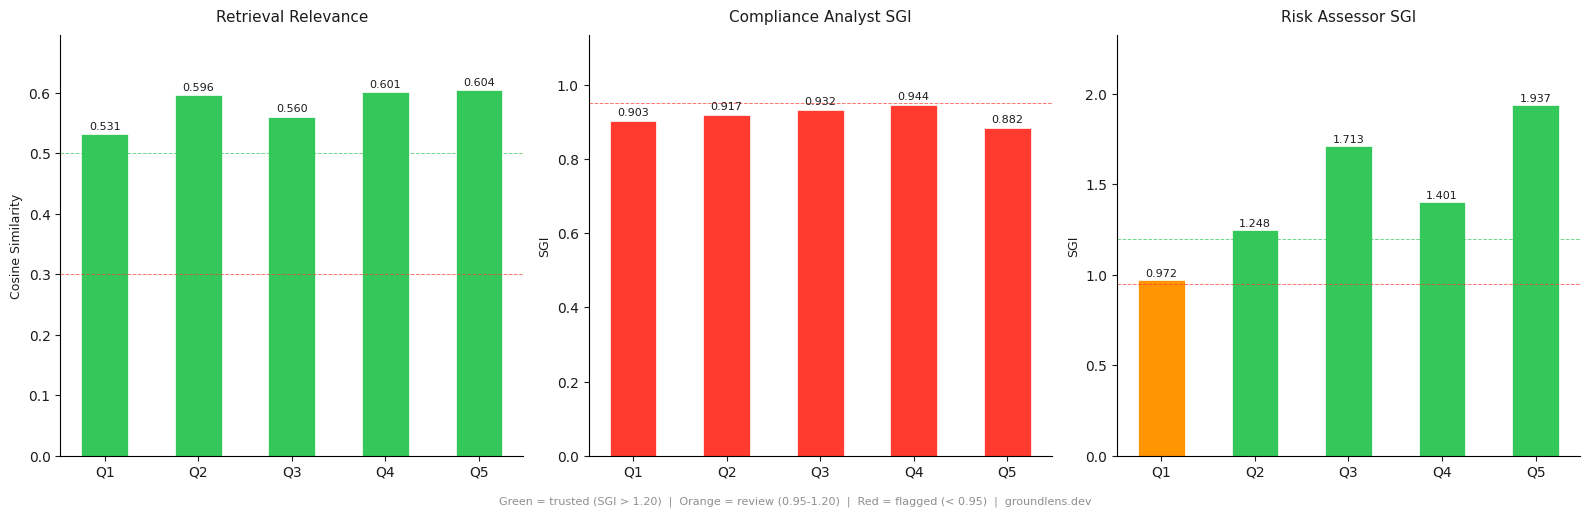

In [10]:
# -- Visualization: Relevance + SGI per query --
APPLE_RED = "#FF3B30"
APPLE_GREEN = "#34C759"
APPLE_ORANGE = "#FF9500"
APPLE_BLUE = "#007AFF"
APPLE_TEXT = "#1C1C1E"

n_queries = len(all_results)
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Collect data
rels = [r["relevance"] for r in all_results]
analyst_sgis = []
assessor_sgis = []
analyst_triages = []
assessor_triages = []

for r in all_results:
    a_step = next((s for s in r["trace"].steps if s.node_name == "compliance_analyst"), None)
    r_step = next((s for s in r["trace"].steps if s.node_name == "risk_assessor"), None)
    analyst_sgis.append(a_step.score.value if a_step else 0)
    assessor_sgis.append(r_step.score.value if r_step else 0)
    analyst_triages.append(a_step.triage if a_step else "unknown")
    assessor_triages.append(r_step.triage if r_step else "unknown")

labels = [f"Q{i+1}" for i in range(n_queries)]

def triage_color(t):
    if t == "flagged": return APPLE_RED
    if t == "review": return APPLE_ORANGE
    return APPLE_GREEN

# Panel 1: Retrieval Relevance
colors1 = [APPLE_GREEN if r >= 0.5 else (APPLE_ORANGE if r >= 0.3 else APPLE_RED) for r in rels]
bars1 = axes[0].bar(labels, rels, color=colors1, width=0.5, edgecolor="white", linewidth=0.5)
for bar, val in zip(bars1, rels):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                 f"{val:.3f}", ha="center", va="bottom", fontsize=8, color=APPLE_TEXT)
axes[0].set_title("Retrieval Relevance", fontsize=11, color=APPLE_TEXT, pad=10)
axes[0].set_ylabel("Cosine Similarity", fontsize=9, color=APPLE_TEXT)
axes[0].set_ylim(0, max(rels) * 1.15 if rels else 1)
axes[0].axhline(y=0.5, color=APPLE_GREEN, linestyle="--", linewidth=0.7, alpha=0.7)
axes[0].axhline(y=0.3, color=APPLE_RED, linestyle="--", linewidth=0.7, alpha=0.7)
axes[0].spines["top"].set_visible(False)
axes[0].spines["right"].set_visible(False)
axes[0].tick_params(colors=APPLE_TEXT)

# Panel 2: Analyst SGI
colors2 = [triage_color(t) for t in analyst_triages]
bars2 = axes[1].bar(labels, analyst_sgis, color=colors2, width=0.5, edgecolor="white", linewidth=0.5)
for bar, val in zip(bars2, analyst_sgis):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 f"{val:.3f}", ha="center", va="bottom", fontsize=8, color=APPLE_TEXT)
axes[1].set_title("Compliance Analyst SGI", fontsize=11, color=APPLE_TEXT, pad=10)
axes[1].set_ylabel("SGI", fontsize=9, color=APPLE_TEXT)
axes[1].set_ylim(0, max(analyst_sgis) * 1.2 if analyst_sgis else 2)
axes[1].axhline(y=1.20, color=APPLE_GREEN, linestyle="--", linewidth=0.7, alpha=0.7)
axes[1].axhline(y=0.95, color=APPLE_RED, linestyle="--", linewidth=0.7, alpha=0.7)
axes[1].spines["top"].set_visible(False)
axes[1].spines["right"].set_visible(False)
axes[1].tick_params(colors=APPLE_TEXT)

# Panel 3: Risk Assessor SGI
colors3 = [triage_color(t) for t in assessor_triages]
bars3 = axes[2].bar(labels, assessor_sgis, color=colors3, width=0.5, edgecolor="white", linewidth=0.5)
for bar, val in zip(bars3, assessor_sgis):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 f"{val:.3f}", ha="center", va="bottom", fontsize=8, color=APPLE_TEXT)
axes[2].set_title("Risk Assessor SGI", fontsize=11, color=APPLE_TEXT, pad=10)
axes[2].set_ylabel("SGI", fontsize=9, color=APPLE_TEXT)
axes[2].set_ylim(0, max(assessor_sgis) * 1.2 if assessor_sgis else 2)
axes[2].axhline(y=1.20, color=APPLE_GREEN, linestyle="--", linewidth=0.7, alpha=0.7)
axes[2].axhline(y=0.95, color=APPLE_RED, linestyle="--", linewidth=0.7, alpha=0.7)
axes[2].spines["top"].set_visible(False)
axes[2].spines["right"].set_visible(False)
axes[2].tick_params(colors=APPLE_TEXT)

fig.text(0.5, -0.02,
    "Green = trusted (SGI > 1.20)  |  Orange = review (0.95-1.20)  |  Red = flagged (< 0.95)  |  groundlens.dev",
    ha="center", fontsize=8, color="#8E8E93")

plt.tight_layout()
plt.savefig("live_pipeline_results.png", dpi=150, bbox_inches="tight")
plt.show()

## 7. Detailed Trace

Full groundlens trace for each query: what was retrieved, what each agent produced, how groundlens scored it.

In [11]:
for i, r in enumerate(all_results):
    print(f"\n{'='*70}")
    print(f"Q{i+1}: {r['question']}")
    print(f"{'='*70}")
    print(f"\nRetrieval relevance: {r['relevance']:.4f}")
    print(f"\n--- Analyst Response (first 400 chars) ---")
    print(r["response"][:400])
    print(f"\n--- Risk Assessment (first 400 chars) ---")
    print(r["summary"][:400])
    print(f"\n--- groundlens Trace ---")
    print(r["trace"].summary())


Q1: What fines apply to companies that deploy prohibited AI practices under the EU AI Act?

Retrieval relevance: 0.5311

--- Analyst Response (first 400 chars) ---
The provided text does **not** include the specific provisions on fines for deploying prohibited AI practices.

What the text does say is that it covers the aim of the Regulation and the establishment of rules and measures in support of innovation, and it begins the chapter on the EU database for high-risk AI systems (Article 71). However, it does **not** contain the penalty/fine article or any wo

--- Risk Assessment (first 400 chars) ---
**Risk assessment: Medium**

Based on the text provided, the material **does not include the sanctions/fines provision** for prohibited AI practices. It only shows:
- the Regulation’s purpose and innovation support recitals, and
- the start of **Chapter VIII** and **Article 71** on the **EU database for high-risk AI systems**.

## Specific obligations identified
From the provided excerpt,

## 8. HTML Triage Report

groundlens generates a self-contained HTML report with expandable details for every pipeline step. This is what an operations team reviews.

In [12]:
# Combine all traces into one for the full report
from groundlens.integrations.langgraph.trace import AgentTrace

combined_trace = AgentTrace()
for r in all_results:
    combined_trace.steps.extend(r["trace"].steps)

html_report = combined_trace.to_html("groundlens_triage_report.html")
print(f"HTML report: groundlens_triage_report.html ({len(html_report):,} bytes)")
print(f"Total steps scored: {combined_trace.total_steps}")
print(f"Trusted: {combined_trace.trusted_steps} | Review: {combined_trace.review_steps} | Flagged: {combined_trace.flagged_steps}")

# Display inline
from IPython.display import HTML, display
display(HTML(html_report))

HTML report: groundlens_triage_report.html (78,059 bytes)
Total steps scored: 10
Trusted: 4 | Review: 1 | Flagged: 5


## 9. Sabotage Test: Wrong Context, Same Question

Everything above used correct retrieval. But what happens when the retriever pulls the **wrong section**?

Below, we deliberately feed chunks about **GPAI systemic risk classification** when the question asks about **fines**. The LLM receives authoritative-sounding regulation text -- just not the right regulation text.

This tests whether groundlens catches the failure, and **why** each metric flags it:

- **Retrieval relevance** drops because the retrieved text doesn't match the question topic.
- **SGI** drops because the model struggles to ground its answer in irrelevant context -- it hedges, bridges from training data, or fabricates connections, all of which push the response embedding away from the provided text.

When both metrics agree, you have high confidence something went wrong. The complementary case -- high SGI but low relevance -- would mean the model faithfully answered from the wrong source. That's an even subtler failure that only retrieval relevance catches.

In [14]:
# -- Find chunks about different topics for the sabotage test --

sabotage_question = "What fines apply to companies that deploy prohibited AI practices?"

# Correct retrieval
correct_ctx, correct_scores = retrieve_chunks(sabotage_question, top_k=3)

# Sabotaged retrieval: search for a DIFFERENT topic and use those chunks
wrong_ctx, wrong_scores = retrieve_chunks(
    "What computation threshold classifies a model as systemic risk?",
    top_k=3,
)

# Run the analyst with WRONG context
gl_sabotage = GroundlensLangGraphCallback()
sabotage_messages = [
    SystemMessage(content=(
        "You are an EU AI Act compliance expert. Answer the question using "
        "ONLY the regulation text provided. Cite specific article numbers."
    )),
    HumanMessage(content=(
        f"Regulation text:\n{wrong_ctx}\n\n"
        f"Question: {sabotage_question}"
    )),
]
sabotage_result = llm.invoke(sabotage_messages, config={"callbacks": [gl_sabotage]})

# Metrics
rel_wrong = retrieval_relevance(sabotage_question, wrong_ctx)
rel_correct = retrieval_relevance(sabotage_question, correct_ctx)
sgi_sabotage = compute_sgi(
    question=sabotage_question,
    context=wrong_ctx,
    response=sabotage_result.content,
)

print(f"Question: {sabotage_question}")
print(f"\nRetrieved: WRONG chunks (systemic risk classification, not fines)")
print(f"\nLLM response (first 400 chars):")
print(sabotage_result.content[:400])
print(f"\n--- Metrics ---")
print(f"Retrieval relevance (WRONG context):   {rel_wrong:.4f}")
print(f"Retrieval relevance (correct context):  {rel_correct:.4f}")
print(f"Relevance drop: {rel_correct - rel_wrong:.4f}")
print(f"\nSGI: {sgi_sabotage.value:.3f} ({'flagged' if sgi_sabotage.flagged else 'passed'})")

# Interpret results based on actual scores
if sgi_sabotage.flagged:
    print(f"\nBoth metrics caught the sabotage:")
    print(f"  SGI says: not grounded (model couldn't anchor its answer in irrelevant text)")
    print(f"  Relevance says: wrong context retrieved (topic mismatch)")
    print(f"\nDouble coverage -- two independent signals, same conclusion.")
else:
    print(f"\nSGI says: grounded -- it sees nothing wrong (the response follows the text)")
    print(f"Relevance says: wrong context retrieved (topic mismatch)")
    print(f"\nThis is the blind spot: faithful answer from the wrong source.")
    print(f"Only retrieval relevance catches it.")

Question: What fines apply to companies that deploy prohibited AI practices?

Retrieved: WRONG chunks (systemic risk classification, not fines)

LLM response (first 400 chars):
Under **Article 99(3)**, infringements of the **prohibited AI practices** in **Article 5** are subject to administrative fines of **up to EUR 35 000 000** or, if the offender is an undertaking, **up to 7 % of its total worldwide annual turnover for the preceding financial year, whichever is higher**.

Article 99(3) also provides that, for **SMEs**, including start-ups, those amounts shall be the *

--- Metrics ---
Retrieval relevance (WRONG context):   0.2740
Retrieval relevance (correct context):  0.4528
Relevance drop: 0.1788

SGI: 0.670 (flagged)

Both metrics caught the sabotage:
  SGI says: not grounded (model couldn't anchor its answer in irrelevant text)
  Relevance says: wrong context retrieved (topic mismatch)

Double coverage -- two independent signals, same conclusion.


---

## Summary

### What this notebook demonstrated

1. **Loaded the real EU AI Act PDF** (144 pages), extracted text, chunked it, built a vector index.

2. **Built a 3-agent LangGraph pipeline** (retriever + compliance analyst + risk assessor) powered by GPT-5.4-mini, running real LLM calls over extracted regulation text.

3. **groundlens monitored every LLM call** with zero instrumentation inside the agents. One callback, automatic SGI scoring.

4. **Sabotage test** (Section 9): deliberately feeding wrong context triggered both retrieval relevance and SGI flags -- two independent signals confirming the failure. In cases where the model faithfully answers from wrong context, only retrieval relevance would catch it.

### Deploy this tomorrow

```python
from groundlens.integrations.langgraph import GroundlensLangGraphCallback

gl = GroundlensLangGraphCallback()
result = your_pipeline.invoke(input, config={"callbacks": [gl]})

trace = gl.get_trace()
if trace.flagged_steps > 0:
    alert_human_reviewer(trace)
```

One callback. Full pipeline coverage. No second LLM.

### Links

- **GitHub:** [github.com/groundlens-dev/groundlens](https://github.com/groundlens-dev/groundlens)
- **Docs:** [groundlens.dev](https://groundlens.dev)
- **Paper (SGI):** [arXiv:2512.13771](https://arxiv.org/abs/2512.13771)
- **Paper (DGI/Hallucinations Taxonomy):** [arXiv:2602.13224](https://arxiv.org/abs/2602.13224)